## Parte 1 — Cámara oscura y procesamiento digital

3. Captura con cámara oscura + ecualización HSV

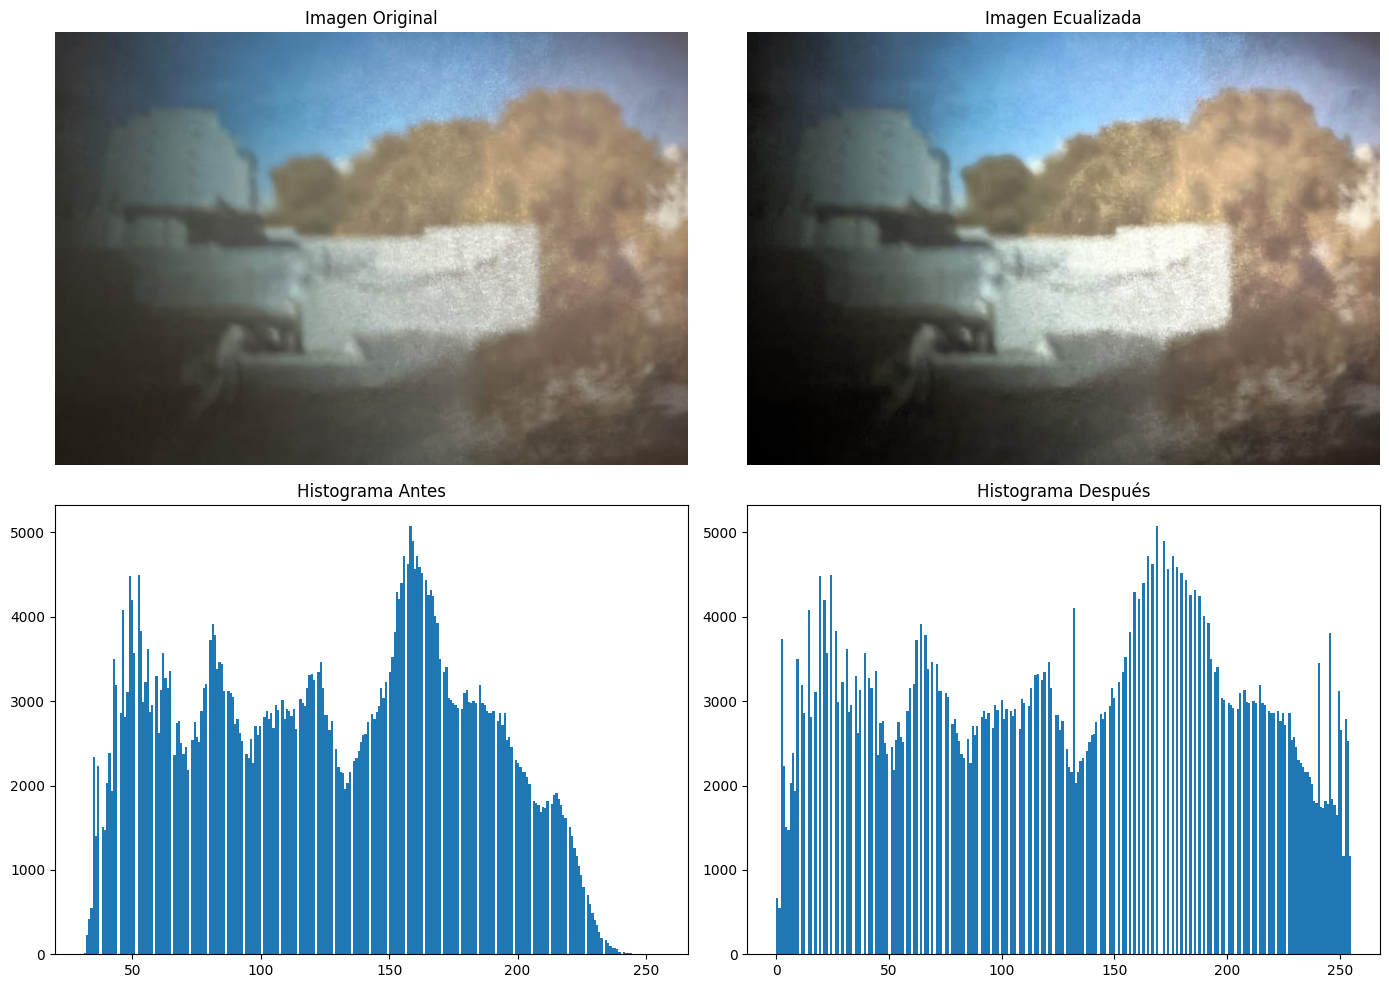

In [1]:
import cv2
import matplotlib.pyplot as plt

#Leer imagen
imagen = cv2.imread(
    r"C:\Users\usuario\zambrano-michell-pdi-1c-2026\007 - fotografia_digital\imagenes\originales\imagen_camara_oscura.jpeg"
)

#Verificar carga
if imagen is None:
    print("Error al cargar la imagen")
    exit()

#Convertir a RGB
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

#Convertir a HSV
imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

#Separar canales
h, s, v = cv2.split(imagen_hsv)

#Ecualizar canal V
v_ecualizado = cv2.equalizeHist(v)

#Recomponer imagen HSV
imagen_hsv_eq = cv2.merge([h, s, v_ecualizado])

#Convertir nuevamente a RGB
imagen_eq_rgb = cv2.cvtColor(imagen_hsv_eq, cv2.COLOR_HSV2RGB)


fig, ax = plt.subplots(2, 2, figsize=(14,10))

#Imagen original
ax[0,0].imshow(imagen_rgb)
ax[0,0].set_title("Imagen Original")
ax[0,0].axis("off")

#Imagen ecualizada
ax[0,1].imshow(imagen_eq_rgb)
ax[0,1].set_title("Imagen Ecualizada")
ax[0,1].axis("off")

#Histograma antes
ax[1,0].hist(v.ravel(), bins=256)
ax[1,0].set_title("Histograma Antes")

#Histograma después
ax[1,1].hist(v_ecualizado.ravel(), bins=256)
ax[1,1].set_title("Histograma Después")

plt.tight_layout()
plt.show()

In [2]:
#Convertir nuevamente a RGB
imagen_eq_rgb = cv2.cvtColor(imagen_hsv_eq, cv2.COLOR_HSV2RGB)

#Guardar imagen procesada
cv2.imwrite(
    r"C:\Users\usuario\zambrano-michell-pdi-1c-2026\007 - fotografia_digital\imagenes\procesadas\imagen_ecualizada.jpeg",
    cv2.cvtColor(imagen_eq_rgb, cv2.COLOR_RGB2BGR)
)

True

## Preguntas guía
¿Qué mejoró visualmente?
Mejoró el contraste general de la imagen y la percepción de detalles en zonas oscuras. La imagen ecualizada en el canal V presenta una iluminación más equilibrada y una mejor diferenciación entre objetos y fondo.

¿Qué información se perdió?
En sí, no se perdieron detalles pero si hubo una amplificación del ruido y además algunas zonas todavía siguen estando poco definidas.

¿Qué limitaciones tiene la cámara oscura?
En general, la cámara oscura suele producir imágenes con baja nitidez, poca iluminación y contraste bajo. Además de esto, al utilizar este método resulta más evidente el ruido el cual es muy común en estas imágenes.

¿Por qué se ecualiza el canal V y no RGB directamente?
Porque el canal V representa únicamente el brillo de la imagen. Ecualizar directamente los canales RGB puede alterar los colores originales y generar resultados poco naturales.